In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np

In [ ]:
import torch
from tqdm.notebook import tqdm

In [ ]:
from torchvision import datasets, transforms
mnist_train = datasets.MNIST(root="./datasets", train=True, transform=transforms.ToTensor(), download=True)
mnist_test = datasets.MNIST(root="./datasets", train=False, transform=transforms.ToTensor(), download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 129MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 55.6MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 120MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


In [ ]:
print("Number of MNIST training examples: {}".format(len(mnist_train)))
print("Number of MNIST test examples: {}".format(len(mnist_test)))

Number of MNIST training examples: 60000
Number of MNIST test examples: 10000


Default image shape: torch.Size([1, 28, 28])
Reshaped image shape: torch.Size([28, 28])
The label for this image: 1


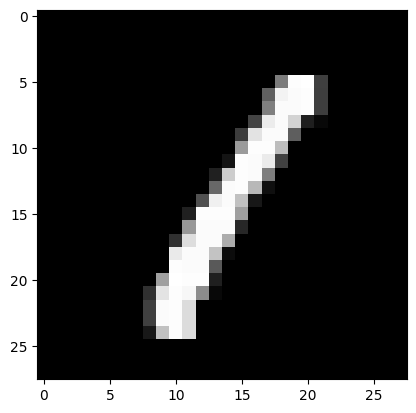

In [ ]:
# Pick out the 4th (0-indexed) example from the training set
image, label = mnist_train[3]

# Plot the image
print("Default image shape: {}".format(image.shape))
image = image.reshape([28,28])
print("Reshaped image shape: {}".format(image.shape))
plt.imshow(image, cmap="gray")

# Print the label
print("The label for this image: {}".format(label))

In [ ]:
train_loader = torch.utils.data.DataLoader(mnist_train, batch_size=100, shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=100, shuffle=False)

In [ ]:
data_train_iter = iter(train_loader)
images, labels = next(data_train_iter)

print("Shape of images:", images.shape)
print("Shape of labels:", labels.shape)

Shape of images: torch.Size([100, 1, 28, 28])
Shape of labels: torch.Size([100])


In [ ]:
x = images.view(-1, 28*28)
print("The shape of input x: {}".format(x.shape))

The shape of input x: torch.Size([100, 784])


In [ ]:
# Randomly initialize weights W
W = torch.randn(784, 10)/np.sqrt(784)
W.requires_grad_()

# Initialize bias b as 0s
b = torch.zeros(10, requires_grad=True)

In [ ]:
# Linear transformation with W and b
y = torch.matmul(x, W) + b

In [ ]:
print(y[0,:])

tensor([-0.2588, -0.6046,  0.2361,  0.2200, -0.1423,  0.2114,  0.0927,  0.1058,
        -0.4007, -0.6636], grad_fn=<SelectBackward0>)


In [ ]:
# Option 1: Softmax to probabilities from equation
py_eq = torch.exp(y) / torch.sum(torch.exp(y), dim=1, keepdim=True)
print("py[0] from equation: {}".format(py_eq[0]))

# Option 2: Softmax to probabilities with torch.nn.functional
import torch.nn.functional as F
py = F.softmax(y, dim=1)
print("py[0] with torch.nn.functional.softmax: {}".format(py[0]))

py[0] from equation: tensor([0.0828, 0.0586, 0.1358, 0.1336, 0.0930, 0.1325, 0.1176, 0.1192, 0.0718,
        0.0552], grad_fn=<SelectBackward0>)
py[0] with torch.nn.functional.softmax: tensor([0.0828, 0.0586, 0.1358, 0.1336, 0.0930, 0.1325, 0.1176, 0.1192, 0.0718,
        0.0552], grad_fn=<SelectBackward0>)


In [ ]:
print(labels.shape)

torch.Size([100])


In [ ]:
# Cross-entropy loss from equation
cross_entropy_eq = torch.mean(-torch.log(py_eq)[range(labels.shape[0]),labels])
print("cross entropy from equation: {}".format(cross_entropy_eq))

# Option 2: cross-entropy loss with torch.nn.functional
cross_entropy = F.cross_entropy(y, labels)
print("cross entropy with torch.nn.functional.cross_entropy: {}".format(cross_entropy))

cross entropy from equation: 2.388983964920044
cross entropy with torch.nn.functional.cross_entropy: 2.388984203338623


In [ ]:
# Optimizer
optimizer = torch.optim.SGD([W,b], lr=0.1)

In [ ]:
cross_entropy.backward()

In [ ]:
b.grad


tensor([-0.0122, -0.0219,  0.0274,  0.0354,  0.0380,  0.0493, -0.0300,  0.0180,
        -0.0935, -0.0105])

In [ ]:
optimizer.step()

In [ ]:
b

tensor([ 0.0012,  0.0022, -0.0027, -0.0035, -0.0038, -0.0049,  0.0030, -0.0018,
         0.0094,  0.0011], requires_grad=True)

In [ ]:
print("b.grad before zero_grad(): {}".format(b.grad))
optimizer.zero_grad()
print("b.grad after zero_grad(): {}".format(b.grad))

b.grad before zero_grad(): tensor([-0.0122, -0.0219,  0.0274,  0.0354,  0.0380,  0.0493, -0.0300,  0.0180,
        -0.0935, -0.0105])
b.grad after zero_grad(): None


In [ ]:
# Iterate through train set minibatchs
for images, labels in tqdm(train_loader):
    # Zero out the gradients
    optimizer.zero_grad()

    # Forward pass
    x = images.view(-1, 28*28)
    y = torch.matmul(x, W) + b
    cross_entropy = F.cross_entropy(y, labels)
    # Backward pass
    cross_entropy.backward()
    optimizer.step()

  0%|          | 0/600 [00:00<?, ?it/s]

In [ ]:
correct = 0
total = len(mnist_test)

with torch.no_grad():
    # Iterate through test set minibatchs
    for images, labels in tqdm(test_loader):
        # Forward pass
        x = images.view(-1, 28*28)
        y = torch.matmul(x, W) + b

        predictions = torch.argmax(y, dim=1)
        correct += torch.sum((predictions == labels).float())

print('Test accuracy: {}'.format(correct/total))

  0%|          | 0/100 [00:00<?, ?it/s]

Test accuracy: 0.901199996471405


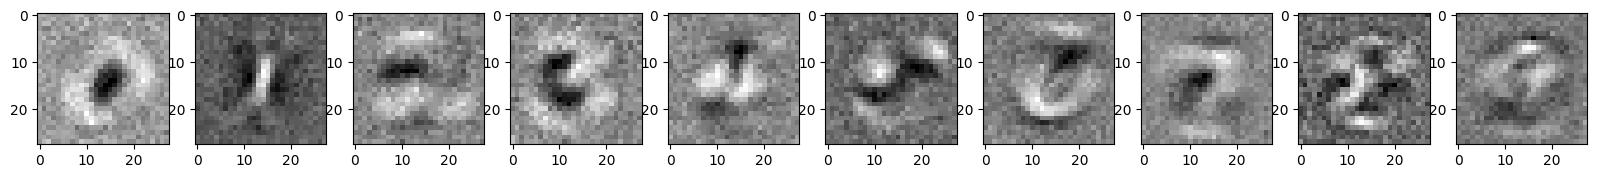

In [ ]:
# Get weights
fig, ax = plt.subplots(1, 10, figsize=(20, 2))

for digit in range(10):
    ax[digit].imshow(W[:,digit].detach().view(28,28), cmap='gray')

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from tqdm.notebook import tqdm

class MNIST_Logistic_Regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(784, 10)

    def forward(self, x):
        return self.lin(x)

# Load the data
mnist_train = datasets.MNIST(root="./datasets", train=True, transform=transforms.ToTensor(), download=True)
mnist_test = datasets.MNIST(root="./datasets", train=False, transform=transforms.ToTensor(), download=True)
train_loader = torch.utils.data.DataLoader(mnist_train, batch_size=100, shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=100, shuffle=False)

## Training
# Instantiate model
model = MNIST_Logistic_Regression()

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# Iterate through train set minibatchs
for images, labels in tqdm(train_loader):
    # Zero out the gradients
    optimizer.zero_grad()

    # Forward pass
    x = images.view(-1, 28*28)
    y = model(x)
    loss = criterion(y, labels)
    # Backward pass
    loss.backward()
    optimizer.step()

## Testing
correct = 0
total = len(mnist_test)

with torch.no_grad():
    # Iterate through test set minibatchs
    for images, labels in tqdm(test_loader):
        # Forward pass
        x = images.view(-1, 28*28)
        y = model(x)

        predictions = torch.argmax(y, dim=1)
        correct += torch.sum((predictions == labels).float())

print('Test accuracy: {}'.format(correct/total))

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Test accuracy: 0.9028000235557556


In [ ]:
# Clone repo
!git clone https://github.com/gargi0404/IntroductionToMachineLearning.git

# Go into repo (fix double folder issue too)
%cd IntroductionToMachineLearning

# Create a dummy file (IMPORTANT if nothing exists)
!echo "# My ML Repo" > README.md

# Git config
!git config --global user.email "gargishindepatil06@gmail.com"
!git config --global user.name "gargi0404"

# Add + commit
!git add .
!git commit -m "Initial commit"

# Create main branch and push
!git branch -M main
!git push -u origin main

Cloning into 'IntroductionToMachineLearning'...
/content/IntroductionToMachineLearning/IntroductionToMachineLearning/IntroductionToMachineLearning
[main (root-commit) 4d548c3] Initial commit
 1 file changed, 1 insertion(+)
 create mode 100644 README.md
fatal: could not read Username for 'https://github.com': No such device or address
